# Chapter 11: Training Deep Neural Networks

## Overview

Training deep neural networks presents unique challenges that don't occur with shallow networks:

1. **Vanishing/Exploding Gradients**: Gradients become too small or too large when flowing backward through many layers
2. **Insufficient Training Data**: Large networks with millions of parameters need substantial labeled data
3. **Slow Training**: Deep networks can take extremely long to train
4. **Overfitting**: Models with millions of parameters easily overfit, especially with limited data

This notebook will explore these problems and their solutions through practical examples.

## Setup: Import Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import pandas as pd

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

c:\Users\ASUS\anaconda3\envs\conda_env\lib\site-packages\google\api_core\_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.11) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


TensorFlow version: 2.15.0
Keras version: 3.12.0


## 1. The Vanishing/Exploding Gradients Problem

### Problem Description

During backpropagation in deep networks, gradients often:
- Become progressively **smaller** (vanishing) as they flow backward → lower layers barely learn
- Become progressively **larger** (exploding) as they flow backward → divergence and instability

### Root Causes (Glorot & Bengio, 2010)

1. **Poor weight initialization** (e.g., normal distribution with mean=0, std=1)
2. **Sigmoid activation functions** that saturate (output near 0 or 1)
3. **Variance increases** through layers, causing saturation

When sigmoid functions saturate, their derivatives approach 0, leaving virtually no gradient to propagate backward.

Let's demonstrate this problem:

In [2]:
# Load MNIST dataset for demonstrations
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.mnist.load_data()

# Normalize pixel values to [0, 1]
X_train_full = X_train_full / 255.0
X_test = X_test / 255.0

# Create validation set
X_valid, X_train = X_train_full[:5000], X_train_full[5000:]
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

print(f"Training set size: {X_train.shape}")
print(f"Validation set size: {X_valid.shape}")
print(f"Test set size: {X_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 62s 5us/step
Training set size: (55000, 28, 28)
Validation set size: (5000, 28, 28)
Test set size: (10000, 28, 28)


### Demonstrating the Vanishing Gradient Problem

Let's create a deep network with poor initialization and sigmoid activations to see the problem:

In [3]:
# Create a deep network with POOR initialization (glorot_uniform with sigmoid)
# This will demonstrate the vanishing gradient problem

model_poor = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="sigmoid"),
    keras.layers.Dense(200, activation="sigmoid"),
    keras.layers.Dense(100, activation="sigmoid"),
    keras.layers.Dense(50, activation="sigmoid"),
    keras.layers.Dense(10, activation="softmax")
])

model_poor.summary()

c:\Users\ASUS\anaconda3\envs\conda_env\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 200)            │        60,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321,360 (1.23 MB)

 Trainable params: 321,360 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# Compile and train briefly to observe gradient behavior
model_poor.compile(loss="sparse_categorical_crossentropy",
                   optimizer="sgd",
                   metrics=["accuracy"])

history_poor = model_poor.fit(X_train, y_train, epochs=5,
                              validation_data=(X_valid, y_valid),
                              verbose=1)

print("\nNote: Training is slow and accuracy improves slowly due to vanishing gradients!")

Epoch 1/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.1099 - loss: 2.3040 - val_accuracy: 0.1126 - val_loss: 2.3010
Epoch 2/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1128 - loss: 2.3010 - val_accuracy: 0.1126 - val_loss: 2.2999
Epoch 3/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1157 - loss: 2.2998 - val_accuracy: 0.1126 - val_loss: 2.2986
Epoch 4/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.1197 - loss: 2.2984 - val_accuracy: 0.1126 - val_loss: 2.2971
Epoch 5/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1239 - loss: 2.2968 - val_accuracy: 0.1126 - val_loss: 2.2951

Note: Training is slow and accuracy improves slowly due to vanishing gradients!


### Visualizing Gradient Flow

Let's examine the gradients in different layers to see the vanishing gradient problem:

In [5]:
# Function to compute gradients for a batch
def compute_gradients(model, X_batch, y_batch):
    with tf.GradientTape() as tape:
        predictions = model(X_batch, training=True)
        loss = keras.losses.sparse_categorical_crossentropy(y_batch, predictions)
    
    gradients = tape.gradient(loss, model.trainable_variables)
    return gradients

# Get a small batch
X_batch = X_train[:32]
y_batch = y_train[:32]

# Compute gradients
gradients_poor = compute_gradients(model_poor, X_batch, y_batch)

# Analyze gradient magnitudes for each layer's weights
print("Gradient magnitudes (mean absolute value) for each layer:\n")
for i, (var, grad) in enumerate(zip(model_poor.trainable_variables, gradients_poor)):
    if 'kernel' in var.name:  # Only show weight matrices, not biases
        layer_num = var.name.split('/')[0]
        grad_magnitude = tf.reduce_mean(tf.abs(grad)).numpy()
        print(f"{layer_num}: {grad_magnitude:.6e}")

print("\nNotice how gradients become much smaller in earlier layers (vanishing gradient)!")

Gradient magnitudes (mean absolute value) for each layer:

kernel: 4.138343e-04
kernel: 1.819829e-03
kernel: 8.752910e-03
kernel: 5.412571e-02
kernel: 4.484829e-01

Notice how gradients become much smaller in earlier layers (vanishing gradient)!


## 2. Solutions to Gradient Problems

There are several proven solutions to the vanishing/exploding gradients problem:

1. **Better Weight Initialization** (Glorot/He/LeCun)
2. **Better Activation Functions** (ReLU, ELU, SELU instead of sigmoid)
3. **Batch Normalization** (covered in next section)
4. **Gradient Clipping** (for extreme cases)

Let's explore each solution.

## 2.1 Glorot and He Initialization

### The Problem
Random initialization with improper variance causes signals to die out or explode as they pass through layers.

### The Solution
Initialize weights so that the **variance of outputs equals the variance of inputs**.

### Glorot Initialization (Xavier)

**Equation 11-1:**

- Normal distribution: mean = 0, variance = σ² = 1/fan_avg
- Uniform distribution: between -r and +r, where r = √(3/fan_avg)
- fan_avg = (fan_in + fan_out)/2

### Initialization by Activation Function

| Initialization | Activation Functions | Variance (σ²) |
|---------------|---------------------|---------------|
| Glorot | None, tanh, logistic, softmax | 1/fan_avg |
| He | ReLU and variants | 2/fan_in |
| LeCun | SELU | 1/fan_in |

In [6]:
# Demonstrate different initialization strategies

# 1. Default (Glorot) initialization with tanh
model_glorot = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="tanh", kernel_initializer="glorot_uniform"),
    keras.layers.Dense(200, activation="tanh", kernel_initializer="glorot_uniform"),
    keras.layers.Dense(100, activation="tanh", kernel_initializer="glorot_uniform"),
    keras.layers.Dense(10, activation="softmax")
])

print("Model with Glorot initialization and tanh activation:")
model_glorot.summary()

Model with Glorot initialization and tanh activation:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 200)            │        60,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 316,810 (1.21 MB)

 Trainable params: 316,810 (1.21 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# 2. He initialization with ReLU (recommended for ReLU)
model_he = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="relu", kernel_initializer="he_normal"),
    keras.layers.Dense(200, activation="relu", kernel_initializer="he_normal"),
    keras.layers.Dense(100, activation="relu", kernel_initializer="he_normal"),
    keras.layers.Dense(10, activation="softmax")
])

print("Model with He initialization and ReLU activation:")
model_he.summary()

Model with He initialization and ReLU activation:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 200)            │        60,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 316,810 (1.21 MB)

 Trainable params: 316,810 (1.21 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Custom initialization example: He with uniform distribution based on fan_avg
he_avg_init = keras.initializers.VarianceScaling(
    scale=2., mode='fan_avg', distribution='uniform'
)

model_custom = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="sigmoid", kernel_initializer=he_avg_init),
    keras.layers.Dense(100, activation="sigmoid", kernel_initializer=he_avg_init),
    keras.layers.Dense(10, activation="softmax")
])

print("Model with custom He (fan_avg, uniform) initialization:")
model_custom.summary()

Model with custom He (fan_avg, uniform) initialization:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

### Comparing Initialization Methods

Let's train models with different initializations and compare:

In [9]:
# Train Glorot model
model_glorot.compile(loss="sparse_categorical_crossentropy",
                     optimizer="sgd",
                     metrics=["accuracy"])

print("Training with Glorot initialization + tanh...")
history_glorot = model_glorot.fit(X_train, y_train, epochs=10,
                                   validation_data=(X_valid, y_valid),
                                   verbose=0)

print(f"Final validation accuracy: {history_glorot.history['val_accuracy'][-1]:.4f}")

Training with Glorot initialization + tanh...
Final validation accuracy: 0.9668


In [10]:
# Train He model
model_he.compile(loss="sparse_categorical_crossentropy",
                 optimizer="sgd",
                 metrics=["accuracy"])

print("Training with He initialization + ReLU...")
history_he = model_he.fit(X_train, y_train, epochs=10,
                          validation_data=(X_valid, y_valid),
                          verbose=0)

print(f"Final validation accuracy: {history_he.history['val_accuracy'][-1]:.4f}")

Training with He initialization + ReLU...
Final validation accuracy: 0.9712


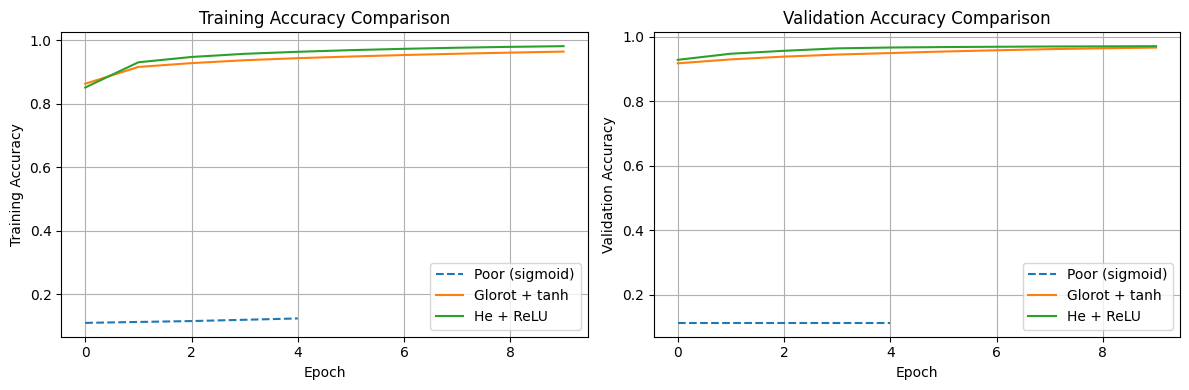


Notice: He initialization + ReLU trains much faster and achieves better accuracy!


In [11]:
# Visualize training comparison
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_poor.history['accuracy'], label='Poor (sigmoid)', linestyle='--')
plt.plot(history_glorot.history['accuracy'], label='Glorot + tanh')
plt.plot(history_he.history['accuracy'], label='He + ReLU')
plt.xlabel('Epoch')
plt.ylabel('Training Accuracy')
plt.title('Training Accuracy Comparison')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_poor.history['val_accuracy'], label='Poor (sigmoid)', linestyle='--')
plt.plot(history_glorot.history['val_accuracy'], label='Glorot + tanh')
plt.plot(history_he.history['val_accuracy'], label='He + ReLU')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy Comparison')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("\nNotice: He initialization + ReLU trains much faster and achieves better accuracy!")

## 2.2 Nonsaturating Activation Functions

Sigmoid and tanh activations saturate (derivative → 0) for large positive/negative inputs, causing vanishing gradients.

### ReLU (Rectified Linear Unit)

**Formula:** ReLU(z) = max(0, z)

**Advantages:**
- Doesn't saturate for positive values
- Very fast to compute
- Gradient is either 0 or 1

**Problem:** Dying ReLUs
- Neurons can "die" and output only 0
- Happens when large negative weights push all inputs to negative

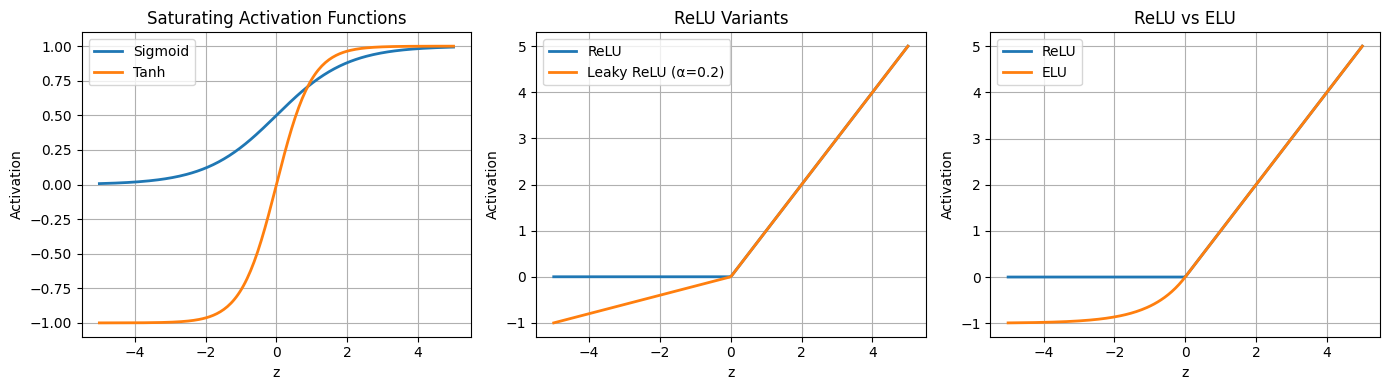

In [12]:
# Visualize different activation functions
z = np.linspace(-5, 5, 200)

# Define activation functions
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def relu(z):
    return np.maximum(0, z)

def leaky_relu(z, alpha=0.01):
    return np.maximum(alpha * z, z)

def elu(z, alpha=1.0):
    return np.where(z < 0, alpha * (np.exp(z) - 1), z)

# Plot activations
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.plot(z, sigmoid(z), label='Sigmoid', linewidth=2)
plt.plot(z, np.tanh(z), label='Tanh', linewidth=2)
plt.xlabel('z')
plt.ylabel('Activation')
plt.title('Saturating Activation Functions')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(z, relu(z), label='ReLU', linewidth=2)
plt.plot(z, leaky_relu(z, 0.2), label='Leaky ReLU (α=0.2)', linewidth=2)
plt.xlabel('z')
plt.ylabel('Activation')
plt.title('ReLU Variants')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(z, relu(z), label='ReLU', linewidth=2)
plt.plot(z, elu(z), label='ELU', linewidth=2)
plt.xlabel('z')
plt.ylabel('Activation')
plt.title('ReLU vs ELU')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Leaky ReLU

**Formula:** LeakyReLU_α(z) = max(αz, z)

**Benefits:**
- Prevents dying ReLUs by allowing small negative slope (typically α=0.01)
- Neurons never truly "die"

**Variants:**
- **RReLU (Randomized Leaky ReLU)**: α picked randomly during training
- **PReLU (Parametric Leaky ReLU)**: α learned via backpropagation

In [13]:
# Model with Leaky ReLU
model_leaky = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, kernel_initializer="he_normal"),
    keras.layers.LeakyReLU(alpha=0.2),
    keras.layers.Dense(100, kernel_initializer="he_normal"),
    keras.layers.LeakyReLU(alpha=0.2),
    keras.layers.Dense(10, activation="softmax")
])

model_leaky.compile(loss="sparse_categorical_crossentropy",
                    optimizer="sgd",
                    metrics=["accuracy"])

print("Model with Leaky ReLU:")
model_leaky.summary()

Model with Leaky ReLU:


c:\Users\ASUS\anaconda3\envs\conda_env\lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Model with PReLU (Parametric Leaky ReLU)
model_prelu = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, kernel_initializer="he_normal"),
    keras.layers.PReLU(),
    keras.layers.Dense(100, kernel_initializer="he_normal"),
    keras.layers.PReLU(),
    keras.layers.Dense(10, activation="softmax")
])

model_prelu.compile(loss="sparse_categorical_crossentropy",
                    optimizer="sgd",
                    metrics=["accuracy"])

print("Model with PReLU (learnable alpha):")
model_prelu.summary()

Model with PReLU (learnable alpha):


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ p_re_lu (PReLU)                 │ (None, 300)            │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ p_re_lu_1 (PReLU)               │ (None, 100)            │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 267,010 (1.02 MB)

 Trainable params: 267,010 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

### ELU (Exponential Linear Unit)

**Equation 11-2:**
```
ELU_α(z) = α(exp(z) - 1)  if z < 0
         = z               if z ≥ 0
```

**Advantages:**
1. Takes negative values → mean activation closer to 0 (helps with vanishing gradient)
2. Nonzero gradient for z < 0 → avoids dead neurons
3. Smooth everywhere when α=1 → faster convergence

**Disadvantage:**
- Slower to compute than ReLU (uses exponential)

In [15]:
# Model with ELU
model_elu = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dense(10, activation="softmax")
])

model_elu.compile(loss="sparse_categorical_crossentropy",
                  optimizer="sgd",
                  metrics=["accuracy"])

print("Training model with ELU activation...")
history_elu = model_elu.fit(X_train, y_train, epochs=10,
                            validation_data=(X_valid, y_valid),
                            verbose=0)

print(f"Final validation accuracy: {history_elu.history['val_accuracy'][-1]:.4f}")

Training model with ELU activation...
Final validation accuracy: 0.9588


### SELU (Scaled ELU)

**Special Property:** Self-normalizing networks
- Network output tends to preserve mean=0 and std=1 during training
- No need for Batch Normalization!

**Requirements for SELU self-normalization:**
1. Input features must be standardized (mean=0, std=1)
2. Use LeCun normal initialization: `kernel_initializer="lecun_normal"`
3. Architecture must be sequential (dense layers only)
4. All hidden layers must use SELU

In [16]:
# Prepare data for SELU (standardize inputs)
# For MNIST images, we need to standardize the pixel values
pixel_means = X_train.mean(axis=0, keepdims=True)
pixel_stds = X_train.std(axis=0, keepdims=True)

X_train_scaled = (X_train - pixel_means) / (pixel_stds + 1e-7)
X_valid_scaled = (X_valid - pixel_means) / (pixel_stds + 1e-7)
X_test_scaled = (X_test - pixel_means) / (pixel_stds + 1e-7)

print(f"Training data - Mean: {X_train_scaled.mean():.4f}, Std: {X_train_scaled.std():.4f}")

Training data - Mean: 0.0000, Std: 0.9550


In [17]:
# Model with SELU (self-normalizing)
model_selu = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.Dense(100, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.Dense(10, activation="softmax")
])

model_selu.compile(loss="sparse_categorical_crossentropy",
                   optimizer="sgd",
                   metrics=["accuracy"])

print("Training model with SELU activation (self-normalizing)...")
history_selu = model_selu.fit(X_train_scaled, y_train, epochs=10,
                              validation_data=(X_valid_scaled, y_valid),
                              verbose=0)

print(f"Final validation accuracy: {history_selu.history['val_accuracy'][-1]:.4f}")

Training model with SELU activation (self-normalizing)...
Final validation accuracy: 0.9642


### Activation Function Comparison

**Recommendation Hierarchy:**
```
SELU > ELU > leaky ReLU > ReLU > tanh > logistic (sigmoid)
```

Let's compare all activation functions:


=== Activation Function Comparison (10 epochs) ===
    Activation  Final Train Acc  Final Val Acc
Poor (sigmoid)         0.123927         0.1126
 Glorot + tanh         0.964673         0.9668
     He + ReLU         0.981764         0.9712
           ELU         0.958473         0.9588
          SELU         0.984091         0.9642


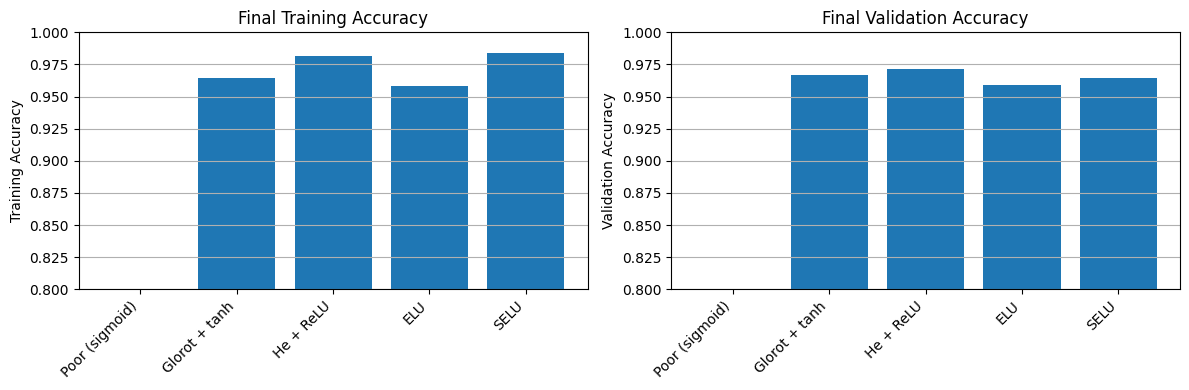

In [18]:
# Compare all activation functions
results = pd.DataFrame({
    'Activation': ['Poor (sigmoid)', 'Glorot + tanh', 'He + ReLU', 'ELU', 'SELU'],
    'Final Train Acc': [
        history_poor.history['accuracy'][-1],
        history_glorot.history['accuracy'][-1],
        history_he.history['accuracy'][-1],
        history_elu.history['accuracy'][-1],
        history_selu.history['accuracy'][-1]
    ],
    'Final Val Acc': [
        history_poor.history['val_accuracy'][-1],
        history_glorot.history['val_accuracy'][-1],
        history_he.history['val_accuracy'][-1],
        history_elu.history['val_accuracy'][-1],
        history_selu.history['val_accuracy'][-1]
    ]
})

print("\n=== Activation Function Comparison (10 epochs) ===")
print(results.to_string(index=False))

# Visualize comparison
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.bar(results['Activation'], results['Final Train Acc'])
plt.ylabel('Training Accuracy')
plt.title('Final Training Accuracy')
plt.xticks(rotation=45, ha='right')
plt.ylim([0.8, 1.0])
plt.grid(True, axis='y')

plt.subplot(1, 2, 2)
plt.bar(results['Activation'], results['Final Val Acc'])
plt.ylabel('Validation Accuracy')
plt.title('Final Validation Accuracy')
plt.xticks(rotation=45, ha='right')
plt.ylim([0.8, 1.0])
plt.grid(True, axis='y')

plt.tight_layout()
plt.show()

## Summary: Part 1 (First 25%)

### Key Problems in Deep Neural Networks
1. **Vanishing Gradients**: Gradients become too small in lower layers
2. **Exploding Gradients**: Gradients become too large, causing instability

### Root Causes
- Poor weight initialization (wrong variance)
- Saturating activation functions (sigmoid, tanh)
- Signal variance changes through layers

### Solutions Covered

#### 1. Proper Weight Initialization
- **Glorot (Xavier)**: For tanh, sigmoid, softmax → σ² = 1/fan_avg
- **He**: For ReLU and variants → σ² = 2/fan_in
- **LeCun**: For SELU → σ² = 1/fan_in

#### 2. Better Activation Functions
- **ReLU**: Fast, doesn't saturate (but can die)
- **Leaky ReLU**: Prevents dying neurons with small negative slope
- **PReLU**: Learnable negative slope
- **ELU**: Smooth, mean closer to 0, no dead neurons
- **SELU**: Self-normalizing networks (best for sequential architectures)

#### Recommendation
```
SELU > ELU > Leaky ReLU > ReLU > tanh > sigmoid
```

### Practical Guidelines
1. Use **He initialization** with ReLU/ELU
2. Use **LeCun initialization** with SELU
3. Prefer **ELU** for most cases (good balance)
4. Use **SELU** for deep sequential networks (self-normalizing)
5. Avoid sigmoid/tanh in hidden layers

### Next Section Preview
In the next section, we'll cover:
- Batch Normalization (powerful technique for very deep networks)
- Gradient Clipping (handling extreme gradients)
- Transfer Learning (reusing pretrained models)

---

**Continue to next section for Batch Normalization and more advanced techniques!**

---

## 3. Batch Normalization

### Concept

Batch Normalization (BN) is a powerful technique that adds an operation before or after each hidden layer's activation function. It:
1. **Zero-centers** the inputs
2. **Normalizes** them (standardizes to mean=0, std=1)
3. **Scales and shifts** the result using learned parameters

This significantly reduces the vanishing/exploding gradients problem and allows training much deeper networks.

### The Algorithm

**Equation 11-3: Batch Normalization Algorithm**

For each mini-batch during training:

**Step 1:** Compute mean over mini-batch
```
μ_B = (1/m_B) × Σ(i=1 to m_B) x^(i)
```

**Step 2:** Compute variance over mini-batch
```
σ²_B = (1/m_B) × Σ(i=1 to m_B) (x^(i) - μ_B)²
```

**Step 3:** Normalize (zero-center and standardize)
```
x̂^(i) = (x^(i) - μ_B) / √(σ²_B + ε)
```

**Step 4:** Scale and shift (learned parameters)
```
z^(i) = γ ⊗ x̂^(i) + β
```

**Parameters:**
- **μ_B, σ_B**: Batch statistics (computed during training)
- **γ (gamma)**: Scale parameter (learned)
- **β (beta)**: Shift parameter (learned)
- **ε**: Smoothing term (typically 10⁻⁵)

### Benefits of Batch Normalization

1. **Greatly improves training** of deep networks
2. **Reduces sensitivity** to weight initialization
3. **Allows higher learning rates** → faster training
4. **Acts as a regularizer** → reduces need for dropout
5. **Less sensitive** to activation function choice

### Drawbacks

- Adds complexity to the model
- Runtime penalty during inference (slower predictions)
- Can be fused with previous layer after training to eliminate overhead

### Implementing Batch Normalization

Let's create models with and without Batch Normalization to see the difference:

In [19]:
# Model WITHOUT Batch Normalization (deep network)
model_no_bn = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dense(200, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dense(50, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dense(10, activation="softmax")
])

model_no_bn.compile(loss="sparse_categorical_crossentropy",
                    optimizer="sgd",
                    metrics=["accuracy"])

print("Deep model WITHOUT Batch Normalization:")
model_no_bn.summary()

Deep model WITHOUT Batch Normalization:


c:\Users\ASUS\anaconda3\envs\conda_env\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_8 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 200)            │        60,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321,360 (1.23 MB)

 Trainable params: 321,360 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# Model WITH Batch Normalization (BN after activation)
model_with_bn = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(300, activation="elu", kernel_initializer="he_normal"),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(200, activation="elu", kernel_initializer="he_normal"),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal"),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(50, activation="elu", kernel_initializer="he_normal"),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(10, activation="softmax")
])

model_with_bn.compile(loss="sparse_categorical_crossentropy",
                      optimizer="sgd",
                      metrics=["accuracy"])

print("\nDeep model WITH Batch Normalization:")
model_with_bn.summary()


Deep model WITH Batch Normalization:


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_9 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 784)            │         3,136 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 300)            │         1,200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 200)            │        60,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 200)            │           800 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 50)             │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 327,096 (1.25 MB)

 Trainable params: 324,228 (1.24 MB)

 Non-trainable params: 2,868 (11.20 KB)

In [21]:
# Train both models and compare
print("Training model WITHOUT Batch Normalization...")
history_no_bn = model_no_bn.fit(X_train, y_train, epochs=20,
                                validation_data=(X_valid, y_valid),
                                verbose=0)

print(f"Final validation accuracy (no BN): {history_no_bn.history['val_accuracy'][-1]:.4f}")

print("\nTraining model WITH Batch Normalization...")
history_with_bn = model_with_bn.fit(X_train, y_train, epochs=20,
                                    validation_data=(X_valid, y_valid),
                                    verbose=0)

print(f"Final validation accuracy (with BN): {history_with_bn.history['val_accuracy'][-1]:.4f}")

Training model WITHOUT Batch Normalization...
Final validation accuracy (no BN): 0.9782

Training model WITH Batch Normalization...
Final validation accuracy (with BN): 0.9662


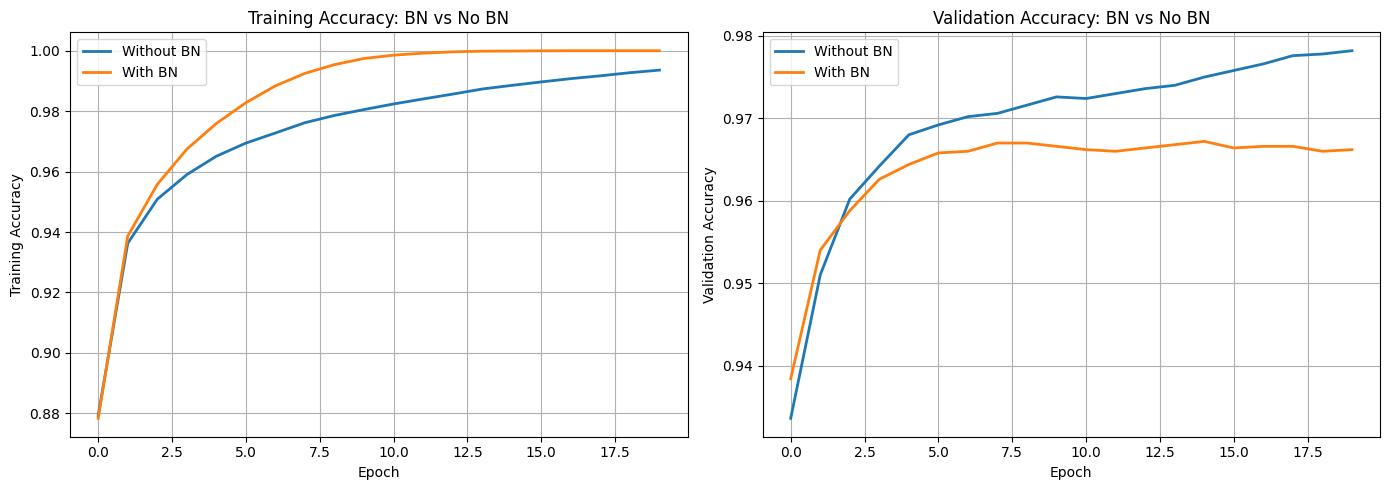


Notice: Batch Normalization significantly speeds up training and improves convergence!


In [22]:
# Visualize the comparison
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_no_bn.history['accuracy'], label='Without BN', linewidth=2)
plt.plot(history_with_bn.history['accuracy'], label='With BN', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Training Accuracy')
plt.title('Training Accuracy: BN vs No BN')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_no_bn.history['val_accuracy'], label='Without BN', linewidth=2)
plt.plot(history_with_bn.history['val_accuracy'], label='With BN', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy: BN vs No BN')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("\nNotice: Batch Normalization significantly speeds up training and improves convergence!")

### Batch Normalization Before Activation (Alternative)

Some practitioners prefer to place BN **before** the activation function. When doing this:
- Set `use_bias=False` in Dense layers (BN's β parameter acts as bias)
- Add the activation as a separate layer

In [23]:
# Model with BN BEFORE activation
model_bn_before = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.BatchNormalization(),
    
    keras.layers.Dense(300, kernel_initializer="he_normal", use_bias=False),
    keras.layers.BatchNormalization(),
    keras.layers.Activation("elu"),
    
    keras.layers.Dense(100, kernel_initializer="he_normal", use_bias=False),
    keras.layers.BatchNormalization(),
    keras.layers.Activation("elu"),
    
    keras.layers.Dense(10, activation="softmax")
])

model_bn_before.compile(loss="sparse_categorical_crossentropy",
                        optimizer="sgd",
                        metrics=["accuracy"])

print("Model with BN BEFORE activation:")
model_bn_before.summary()

Model with BN BEFORE activation:


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_10 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 784)            │         3,136 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 300)            │       235,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 300)            │         1,200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 100)            │        30,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 270,946 (1.03 MB)

 Trainable params: 268,578 (1.02 MB)

 Non-trainable params: 2,368 (9.25 KB)

### Important Hyperparameters

**momentum** (default=0.99): Controls exponential moving average for running statistics
- Formula: `v̂ ← v̂ × momentum + v × (1 - momentum)`
- Use more 9s (e.g., 0.999) for larger datasets
- Smaller values give more weight to recent batches

In [24]:
# Example: Custom momentum for Batch Normalization
model_custom_momentum = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.BatchNormalization(momentum=0.999),  # Higher momentum for large dataset
    keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal"),
    keras.layers.BatchNormalization(momentum=0.999),
    keras.layers.Dense(10, activation="softmax")
])

print("BatchNormalization layer parameters:")
bn_layer = model_custom_momentum.layers[1]
print(f"  momentum: {bn_layer.momentum}")
print(f"  epsilon: {bn_layer.epsilon}")
print(f"  Trainable parameters (gamma, beta): {len(bn_layer.trainable_variables)}")
print(f"  Non-trainable parameters (moving mean, moving variance): {len(bn_layer.non_trainable_variables)}")

BatchNormalization layer parameters:
  momentum: 0.999
  epsilon: 0.001
  Trainable parameters (gamma, beta): 2
  Non-trainable parameters (moving mean, moving variance): 2


---

## 4. Gradient Clipping

For recurrent neural networks or when Batch Normalization isn't sufficient, we can **clip gradients** during backpropagation to prevent explosion.

### Two Approaches

1. **Clip by Value**: Clips each gradient component individually
   - May change gradient direction
   - Simple and fast

2. **Clip by Norm**: Clips entire gradient vector
   - Preserves gradient direction
   - Better for most cases

In [25]:
# Gradient Clipping by Value
# Clips each component between -clipvalue and +clipvalue

model_clip_value = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dense(10, activation="softmax")
])

optimizer_clip_value = keras.optimizers.SGD(clipvalue=1.0)
model_clip_value.compile(loss="sparse_categorical_crossentropy",
                         optimizer=optimizer_clip_value,
                         metrics=["accuracy"])

print("Model with Gradient Clipping by Value (clipvalue=1.0):")
print(f"  Optimizer: {optimizer_clip_value.__class__.__name__}")
print(f"  Clip value: {optimizer_clip_value.clipvalue}")

Model with Gradient Clipping by Value (clipvalue=1.0):
  Optimizer: SGD
  Clip value: 1.0


In [26]:
# Gradient Clipping by Norm (preserves direction)
# Clips entire gradient if its L2 norm exceeds threshold

model_clip_norm = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dense(10, activation="softmax")
])

optimizer_clip_norm = keras.optimizers.SGD(clipnorm=1.0)
model_clip_norm.compile(loss="sparse_categorical_crossentropy",
                        optimizer=optimizer_clip_norm,
                        metrics=["accuracy"])

print("\nModel with Gradient Clipping by Norm (clipnorm=1.0):")
print(f"  Optimizer: {optimizer_clip_norm.__class__.__name__}")
print(f"  Clip norm: {optimizer_clip_norm.clipnorm}")
print("\n  If gradient L2 norm > 1.0, gradient is scaled down to norm=1.0")


Model with Gradient Clipping by Norm (clipnorm=1.0):
  Optimizer: SGD
  Clip norm: 1.0

  If gradient L2 norm > 1.0, gradient is scaled down to norm=1.0


### Visualizing the Effect of Gradient Clipping

Let's create a visual comparison of how different clipping strategies affect gradient vectors:

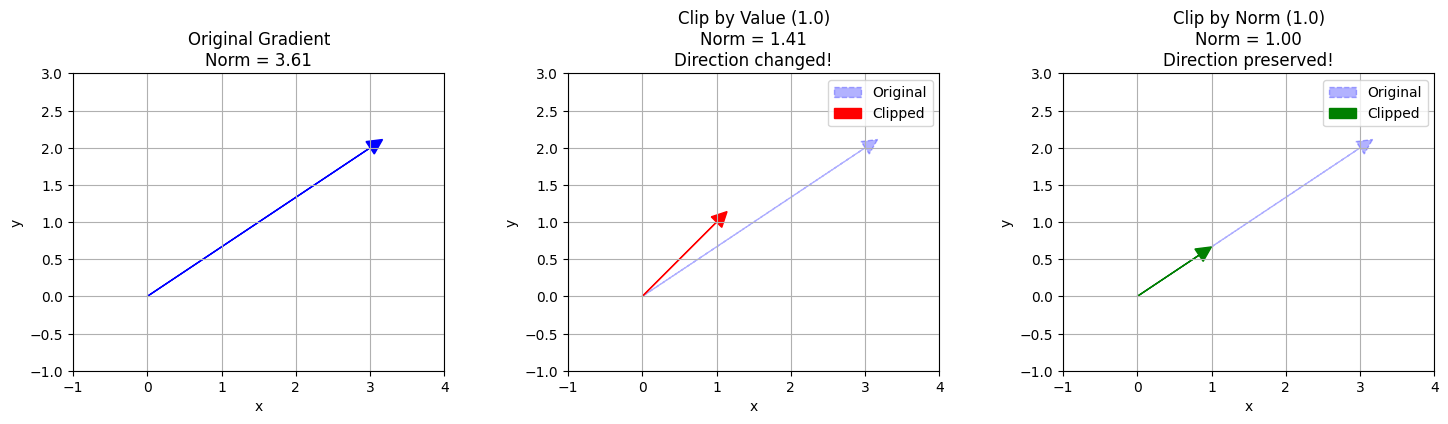

Notice how clip-by-norm preserves the gradient direction, while clip-by-value changes it!


In [27]:
# Visualize gradient clipping
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Original gradient
gradient = np.array([3.0, 2.0])
axes[0].arrow(0, 0, gradient[0], gradient[1], head_width=0.2, head_length=0.2, fc='blue', ec='blue')
axes[0].set_xlim(-1, 4)
axes[0].set_ylim(-1, 3)
axes[0].set_aspect('equal')
axes[0].grid(True)
axes[0].set_title(f'Original Gradient\nNorm = {np.linalg.norm(gradient):.2f}')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')

# Clip by value (clipvalue=1.0)
gradient_clip_value = np.clip(gradient, -1.0, 1.0)
axes[1].arrow(0, 0, gradient[0], gradient[1], head_width=0.2, head_length=0.2, 
              fc='blue', ec='blue', alpha=0.3, linestyle='--', label='Original')
axes[1].arrow(0, 0, gradient_clip_value[0], gradient_clip_value[1], 
              head_width=0.2, head_length=0.2, fc='red', ec='red', label='Clipped')
axes[1].set_xlim(-1, 4)
axes[1].set_ylim(-1, 3)
axes[1].set_aspect('equal')
axes[1].grid(True)
axes[1].set_title(f'Clip by Value (1.0)\nNorm = {np.linalg.norm(gradient_clip_value):.2f}\nDirection changed!')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].legend()

# Clip by norm (clipnorm=1.0)
norm = np.linalg.norm(gradient)
gradient_clip_norm = gradient / norm if norm > 1.0 else gradient
axes[2].arrow(0, 0, gradient[0], gradient[1], head_width=0.2, head_length=0.2, 
              fc='blue', ec='blue', alpha=0.3, linestyle='--', label='Original')
axes[2].arrow(0, 0, gradient_clip_norm[0], gradient_clip_norm[1], 
              head_width=0.2, head_length=0.2, fc='green', ec='green', label='Clipped')
axes[2].set_xlim(-1, 4)
axes[2].set_ylim(-1, 3)
axes[2].set_aspect('equal')
axes[2].grid(True)
axes[2].set_title(f'Clip by Norm (1.0)\nNorm = {np.linalg.norm(gradient_clip_norm):.2f}\nDirection preserved!')
axes[2].set_xlabel('x')
axes[2].set_ylabel('y')
axes[2].legend()

plt.tight_layout()
plt.show()

print("Notice how clip-by-norm preserves the gradient direction, while clip-by-value changes it!")

---

## 5. Reusing Pretrained Layers (Transfer Learning)

### Concept

Instead of training a neural network from scratch, we can **reuse layers** from a model that was trained on a similar task. This approach:
- **Dramatically speeds up training**
- **Requires less data**
- Often achieves **better performance**

### Why Transfer Learning Works

Lower layers learn **general features** (edges, textures, basic patterns) that are useful across many tasks. Higher layers learn **task-specific features**.

### Strategy

1. **Find a similar task**: Look for existing model solving related problem
2. **Reuse lower layers**: They contain general feature detectors
3. **Replace output layer**: Add new output for your specific task
4. **Freeze & train**: Initially freeze reused layers, train only new layers
5. **Fine-tune** (optional): Unfreeze some top layers and train with lower learning rate

### Guidelines

- **More similar tasks** → reuse more layers
- **More training data** → unfreeze more layers for fine-tuning
- **Less training data** → keep more layers frozen
- Start with frozen layers, then progressively unfreeze from top down
- **Reduce learning rate** when unfreezing to avoid destroying fine-tuned weights

### Transfer Learning Demo

Let's demonstrate transfer learning by:
1. Training a model on the full MNIST dataset (digits 0-9)
2. Reusing its layers for a binary classification task (classifying digits 0-4 vs 5-9)

In [28]:
# Step 1: Train Model A on full MNIST (10-class classification)
print("Step 1: Training Model A on full MNIST dataset...")

model_A = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dense(200, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dense(10, activation="softmax")
])

model_A.compile(loss="sparse_categorical_crossentropy",
                optimizer=keras.optimizers.SGD(learning_rate=0.01),
                metrics=["accuracy"])

history_A = model_A.fit(X_train, y_train, epochs=10,
                        validation_data=(X_valid, y_valid),
                        verbose=0)

print(f"Model A final validation accuracy: {history_A.history['val_accuracy'][-1]:.4f}")

# Save Model A for later reuse
model_A.save("model_A_mnist.h5")
print("\nModel A saved as 'model_A_mnist.h5'")

Step 1: Training Model A on full MNIST dataset...


Model A final validation accuracy: 0.9710

Model A saved as 'model_A_mnist.h5'


In [29]:
# Step 2: Prepare data for binary classification (Task B)
# Task B: Classify digits 0-4 (class 0) vs 5-9 (class 1)

def create_binary_task(X, y):
    """Convert to binary classification: 0-4 vs 5-9"""
    return X, (y >= 5).astype(np.int32)

X_train_B, y_train_B = create_binary_task(X_train, y_train)
X_valid_B, y_valid_B = create_binary_task(X_valid, y_valid)
X_test_B, y_test_B = create_binary_task(X_test, y_test)

print("Binary classification task created:")
print(f"  Training set: {X_train_B.shape}, {np.sum(y_train_B)} positive samples")
print(f"  Validation set: {X_valid_B.shape}, {np.sum(y_valid_B)} positive samples")
print(f"  Class 0: digits 0-4")
print(f"  Class 1: digits 5-9")

Binary classification task created:
  Training set: (55000, 28, 28), 26962 positive samples
  Validation set: (5000, 28, 28), 2442 positive samples
  Class 0: digits 0-4
  Class 1: digits 5-9


In [30]:
# Step 3: Create Model B by reusing layers from Model A
print("\nStep 3: Creating Model B using Transfer Learning...")

# Load the pretrained model
model_A = keras.models.load_model("model_A_mnist.h5")

# Create Model B by reusing all layers except the output layer
model_B_on_A = keras.models.Sequential(model_A.layers[:-1])

# Add new output layer for binary classification
model_B_on_A.add(keras.layers.Dense(1, activation="sigmoid"))

print("\nModel B architecture (reusing Model A's layers):")
model_B_on_A.summary()


Step 3: Creating Model B using Transfer Learning...

Model B architecture (reusing Model A's layers):


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_14 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 200)            │        60,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,800 (1.20 MB)

 Trainable params: 315,800 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
# Step 4: Freeze reused layers (train only the new output layer)
print("\nStep 4: Freezing reused layers...")

for layer in model_B_on_A.layers[:-1]:
    layer.trainable = False

# Compile the model (IMPORTANT: compile after freezing!)
model_B_on_A.compile(loss="binary_crossentropy",
                     optimizer="sgd",
                     metrics=["accuracy"])

print("\nLayer trainable status:")
for layer in model_B_on_A.layers:
    print(f"  {layer.name}: trainable = {layer.trainable}")


Step 4: Freezing reused layers...

Layer trainable status:
  flatten_14: trainable = False
  dense_49: trainable = False
  dense_50: trainable = False
  dense_51: trainable = False
  dense_53: trainable = True


In [32]:
# Step 5: Train with frozen layers (only training the new output layer)
print("\nStep 5: Training Model B with frozen layers...")

history_frozen = model_B_on_A.fit(X_train_B, y_train_B, epochs=4,
                                  validation_data=(X_valid_B, y_valid_B),
                                  verbose=0)

print(f"Validation accuracy after training output layer: {history_frozen.history['val_accuracy'][-1]:.4f}")


Step 5: Training Model B with frozen layers...
Validation accuracy after training output layer: 0.9392


In [33]:
# Step 6: Unfreeze layers and fine-tune with lower learning rate
print("\nStep 6: Unfreezing all layers for fine-tuning...")

for layer in model_B_on_A.layers[:-1]:
    layer.trainable = True

# IMPORTANT: Compile again after unfreezing!
# Use lower learning rate to avoid destroying pretrained weights
optimizer = keras.optimizers.SGD(learning_rate=1e-4)  # Much lower than before
model_B_on_A.compile(loss="binary_crossentropy",
                     optimizer=optimizer,
                     metrics=["accuracy"])

print("All layers unfrozen. Training with lower learning rate (1e-4)...")

history_finetuned = model_B_on_A.fit(X_train_B, y_train_B, epochs=16,
                                     validation_data=(X_valid_B, y_valid_B),
                                     verbose=0)

print(f"Final validation accuracy after fine-tuning: {history_finetuned.history['val_accuracy'][-1]:.4f}")


Step 6: Unfreezing all layers for fine-tuning...
All layers unfrozen. Training with lower learning rate (1e-4)...
Final validation accuracy after fine-tuning: 0.9592


In [34]:
# Compare with training from scratch
print("\n" + "="*60)
print("Comparison: Training same architecture from scratch...")
print("="*60)

model_from_scratch = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dense(200, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dense(1, activation="sigmoid")
])

model_from_scratch.compile(loss="binary_crossentropy",
                           optimizer="sgd",
                           metrics=["accuracy"])

history_scratch = model_from_scratch.fit(X_train_B, y_train_B, epochs=20,
                                         validation_data=(X_valid_B, y_valid_B),
                                         verbose=0)

print(f"Final validation accuracy (from scratch): {history_scratch.history['val_accuracy'][-1]:.4f}")


Comparison: Training same architecture from scratch...
Final validation accuracy (from scratch): 0.9810


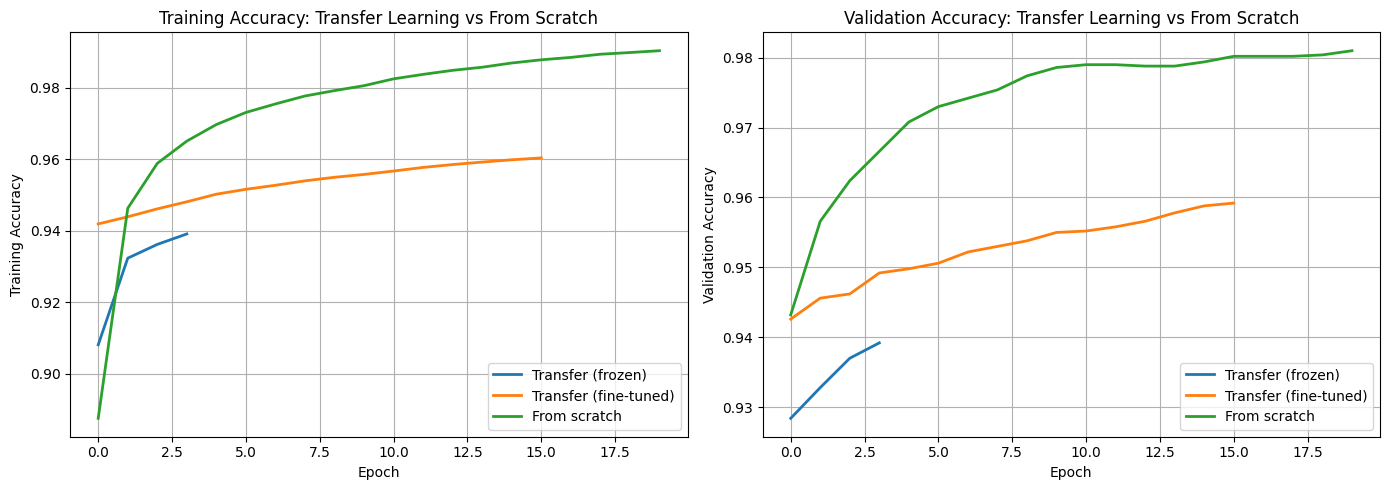


RESULTS SUMMARY:
Transfer Learning (fine-tuned): 0.9592
Training from scratch:          0.9810

Transfer learning typically:
  ✓ Converges faster
  ✓ Requires less data
  ✓ Often achieves better performance


In [35]:
# Visualize the comparison
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_frozen.history['accuracy'], label='Transfer (frozen)', linewidth=2)
plt.plot(history_finetuned.history['accuracy'], label='Transfer (fine-tuned)', linewidth=2)
plt.plot(history_scratch.history['accuracy'], label='From scratch', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Training Accuracy')
plt.title('Training Accuracy: Transfer Learning vs From Scratch')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_frozen.history['val_accuracy'], label='Transfer (frozen)', linewidth=2)
plt.plot(history_finetuned.history['val_accuracy'], label='Transfer (fine-tuned)', linewidth=2)
plt.plot(history_scratch.history['val_accuracy'], label='From scratch', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy: Transfer Learning vs From Scratch')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("RESULTS SUMMARY:")
print("="*60)
print(f"Transfer Learning (fine-tuned): {history_finetuned.history['val_accuracy'][-1]:.4f}")
print(f"Training from scratch:          {history_scratch.history['val_accuracy'][-1]:.4f}")
print("\nTransfer learning typically:")
print("  ✓ Converges faster")
print("  ✓ Requires less data")
print("  ✓ Often achieves better performance")

### Key Takeaways: Transfer Learning

1. **Always compile after freezing/unfreezing** layers
2. **Lower learning rate** for fine-tuning (e.g., 1e-4 instead of 1e-2)
3. **Start with frozen layers**, train new output layer first
4. **Progressively unfreeze** from top down if needed
5. **More similar tasks** → can reuse more layers
6. **More training data** → can unfreeze more layers

### When to Use Transfer Learning

✅ **Use when:**
- Limited training data available
- Similar task exists with trained model
- Want faster training
- Need better performance

❌ **Don't use when:**
- Tasks are very different (e.g., images vs text)
- Have abundant training data and computational resources
- Need absolute maximum performance on very specific task

---

## Summary: Part 2 (Next 25%)

### What We Covered

#### 3. Batch Normalization
- **Algorithm**: Zero-center, normalize, scale, and shift
- **Four parameters per input**: γ (scale), β (shift), μ (mean), σ (variance)
- **Benefits**: Faster training, higher learning rates, acts as regularizer
- **Placement**: Can be after or before activation (before → set `use_bias=False`)
- **Hyperparameters**: momentum (default 0.99), epsilon (default 1e-5)

#### 4. Gradient Clipping
- **Clip by Value**: Clips each component individually (may change direction)
- **Clip by Norm**: Clips entire gradient vector (preserves direction) ✓ Preferred
- **Use cases**: RNNs, very deep networks, when BN isn't enough

#### 5. Transfer Learning
- **Strategy**: Reuse pretrained layers → Replace output → Freeze → Train → Fine-tune
- **Key principle**: Lower layers learn general features, higher layers learn task-specific
- **Benefits**: Faster training, less data needed, better performance
- **Guidelines**: 
  - Always compile after freezing/unfreezing
  - Use lower learning rate for fine-tuning
  - More similar tasks → reuse more layers
  - More data → unfreeze more layers

### Practical Guidelines So Far

**For Deep Networks:**
1. Use **He initialization** with ReLU/ELU or **LeCun** with SELU
2. Use **ELU** or **SELU** activation (avoid sigmoid/tanh in hidden layers)
3. Add **Batch Normalization** for very deep networks
4. Use **gradient clipping** if training RNNs or having gradient explosion
5. Try **transfer learning** whenever possible

**Best Practices:**
- Start simple, add complexity as needed
- Monitor training curves (loss and accuracy)
- Use validation set to detect overfitting
- Always compile after changing trainable status

### Next Section Preview

In the next section (Part 3), we'll cover:
- **Unsupervised & Auxiliary Pretraining**: When you lack labeled data
- **Faster Optimizers**: Momentum, Adam, RMSProp, Nadam
- **Learning Rate Scheduling**: Finding optimal learning rates dynamically

---

**Continue to Part 3 for advanced optimization techniques!**

---

## 6. Unsupervised Pretraining

### Concept

When you **lack labeled data** but have **abundant unlabeled data**, you can use unsupervised learning to pretrain your network.

### Strategy

1. **Train unsupervised model**: Use autoencoder or GAN on unlabeled data
2. **Reuse lower layers**: Transfer learned features to your supervised task
3. **Add output layer**: For your specific classification/regression task
4. **Fine-tune**: Train with your (limited) labeled data

### Historical Context

- This technique **revived Deep Learning in 2006** (using RBMs - Restricted Boltzmann Machines)
- Modern approaches use **autoencoders** or **GANs** (Generative Adversarial Networks)
- Less common now due to better initialization methods and larger labeled datasets
- Still valuable when labeled data is scarce but unlabeled data is plentiful

---

## 7. Pretraining on Auxiliary Task

### Concept

When you have **little labeled data for your target task**, train on a **related task** with abundant labeled data, then transfer the knowledge.

### Strategy

Train on an auxiliary (helper) task that:
- Has abundant training data
- Is related to your target task
- Helps the network learn useful features

Then transfer to your actual task.

### Example 1: Face Recognition

**Problem**: Need to classify specific people, but have few labeled photos

**Solution**:
- **Auxiliary task**: Train to detect if two random face pictures show the same person
- **Data**: Collect millions of random face pairs from the web
- **Transfer**: The network learns general face feature detectors
- **Final task**: Use these features for your specific face classification

### Example 2: Natural Language Processing

**Problem**: Need sentiment analysis, but have limited labeled reviews

**Solution**:
- **Auxiliary task**: Predict masked words in sentences (BERT-style)
- **Data**: Use billions of sentences from the internet (no labels needed!)
- **Transfer**: Network learns language understanding
- **Final task**: Fine-tune for sentiment analysis

### Self-Supervised Learning

**Definition**: Automatically generate labels from the data itself, then use supervised learning techniques.

**Examples**:
- Predict next word in a sentence
- Predict masked words (BERT)
- Predict image rotation
- Colorize grayscale images

This is very powerful because labels are "free" - generated from the data structure itself!

---

## 8. Faster Optimizers

Beyond standard Gradient Descent: **θ ← θ - η∇_θJ(θ)**

Standard SGD can be slow, especially:
- In ravines (one dimension much steeper than others)
- On plateaus (flat regions with small gradients)
- With poor learning rate choice

Let's explore optimizers that address these issues!

### 8.1 Momentum Optimization

**Analogy**: Like a bowling ball rolling downhill - it accumulates velocity and keeps going!

**Equation 11-4: Momentum Algorithm**

```
Step 1: m ← βm - η∇_θJ(θ)     # Update momentum vector
Step 2: θ ← θ + m               # Update parameters
```

**Key Parameters**:
- **β** (momentum): Typically 0.9 (friction parameter, range 0-1)
- **Terminal velocity**: gradient × η × 1/(1-β)
- With β=0.9, momentum makes updates 10× faster than regular GD!

**Benefits**:
- Helps escape plateaus (accumulated momentum pushes through)
- Navigates ravines better (momentum averages out oscillations)
- Accelerates convergence in consistent gradient directions

In [36]:
# Compare SGD vs SGD with Momentum
print("Training models to compare optimizers...")

# Model 1: Standard SGD
model_sgd = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dense(10, activation="softmax")
])

model_sgd.compile(loss="sparse_categorical_crossentropy",
                  optimizer=keras.optimizers.SGD(learning_rate=0.001),
                  metrics=["accuracy"])

history_sgd = model_sgd.fit(X_train, y_train, epochs=20,
                            validation_data=(X_valid, y_valid),
                            verbose=0)

print(f"SGD final validation accuracy: {history_sgd.history['val_accuracy'][-1]:.4f}")

# Model 2: SGD with Momentum
model_momentum = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dense(10, activation="softmax")
])

model_momentum.compile(loss="sparse_categorical_crossentropy",
                       optimizer=keras.optimizers.SGD(learning_rate=0.001, momentum=0.9),
                       metrics=["accuracy"])

history_momentum = model_momentum.fit(X_train, y_train, epochs=20,
                                      validation_data=(X_valid, y_valid),
                                      verbose=0)

print(f"Momentum final validation accuracy: {history_momentum.history['val_accuracy'][-1]:.4f}")

Training models to compare optimizers...
SGD final validation accuracy: 0.9252
Momentum final validation accuracy: 0.9712


### 8.2 Nesterov Accelerated Gradient (NAG)

**Improvement over Momentum**: Measure gradient slightly **ahead** in the momentum direction.

**Equation 11-5: Nesterov Algorithm**

```
Step 1: m ← βm - η∇_θJ(θ + βm)  # Gradient at lookahead position
Step 2: θ ← θ + m                 # Update parameters
```

**Why it's better**:
- More accurate gradient measurement (looks ahead)
- Reduces oscillations
- Generally converges faster than regular momentum
- Acts like a "smart ball" that slows down before hitting a wall

In [37]:
# Model 3: Nesterov Momentum
model_nesterov = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dense(10, activation="softmax")
])

model_nesterov.compile(loss="sparse_categorical_crossentropy",
                       optimizer=keras.optimizers.SGD(learning_rate=0.001, 
                                                      momentum=0.9, 
                                                      nesterov=True),
                       metrics=["accuracy"])

history_nesterov = model_nesterov.fit(X_train, y_train, epochs=20,
                                      validation_data=(X_valid, y_valid),
                                      verbose=0)

print(f"Nesterov final validation accuracy: {history_nesterov.history['val_accuracy'][-1]:.4f}")

Nesterov final validation accuracy: 0.9718


### 8.3 AdaGrad

**Concept**: **Ada**ptive learning rates - scale down gradient along steepest dimensions.

**Equation 11-6: AdaGrad Algorithm**

```
Step 1: s ← s + ∇_θJ(θ) ⊗ ∇_θJ(θ)           # Accumulate squared gradients
Step 2: θ ← θ - η∇_θJ(θ) ⊘ √(s + ε)        # Scale updates
```

Where:
- **⊗** = element-wise multiplication
- **⊘** = element-wise division
- **ε** = smoothing term (typically 10⁻¹⁰)

**How it works**:
- Accumulates squared gradients in **s**
- Scales updates by inverse of accumulated gradient
- Parameters with large gradients get smaller updates
- Parameters with small gradients get larger updates

**Problem**: Learning rate decays too fast → can stop too early
**Not recommended** for deep neural networks!

### 8.4 RMSProp

**Fix for AdaGrad**: Only accumulate **recent** gradients using exponential decay.

**Equation 11-7: RMSProp Algorithm**

```
Step 1: s ← βs + (1-β)∇_θJ(θ) ⊗ ∇_θJ(θ)    # Exponential moving average
Step 2: θ ← θ - η∇_θJ(θ) ⊘ √(s + ε)        # Scale updates
```

**Key difference from AdaGrad**:
- Uses **exponential moving average** instead of sum
- **β** (decay rate): Typically 0.9
- Doesn't accumulate all history → learning rate doesn't decay to zero
- Works much better for deep neural networks!

In [38]:
# Model 4: RMSProp
model_rmsprop = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dense(10, activation="softmax")
])

model_rmsprop.compile(loss="sparse_categorical_crossentropy",
                      optimizer=keras.optimizers.RMSprop(learning_rate=0.001, rho=0.9),
                      metrics=["accuracy"])

history_rmsprop = model_rmsprop.fit(X_train, y_train, epochs=20,
                                    validation_data=(X_valid, y_valid),
                                    verbose=0)

print(f"RMSProp final validation accuracy: {history_rmsprop.history['val_accuracy'][-1]:.4f}")

RMSProp final validation accuracy: 0.9790


### 8.5 Adam (Adaptive Moment Estimation)

**The King of Optimizers**: Combines **Momentum** + **RMSProp**

**Equation 11-8: Adam Algorithm**

```
1. m ← β₁m + (1-β₁)∇_θJ(θ)              # Momentum (first moment)
2. s ← β₂s + (1-β₂)∇_θJ(θ) ⊗ ∇_θJ(θ)    # RMSProp (second moment)
3. m̂ ← m / (1-β₁ᵗ)                      # Bias correction for m
4. ŝ ← s / (1-β₂ᵗ)                      # Bias correction for s
5. θ ← θ - ηm̂ ⊘ √(ŝ + ε)                # Update with scaled momentum
```

**Default Hyperparameters** (work well in most cases):
- **η** (learning rate): 0.001
- **β₁** (momentum decay): 0.9
- **β₂** (scaling decay): 0.999
- **ε** (smoothing): 10⁻⁷

**Why Adam is Popular**:
- Adaptive learning rates (less tuning needed)
- Fast convergence
- Works well across many problem types
- Default choice for many practitioners

**Note**: May generalize slightly worse than Nesterov SGD on some datasets

In [39]:
# Model 5: Adam
model_adam = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dense(10, activation="softmax")
])

model_adam.compile(loss="sparse_categorical_crossentropy",
                   optimizer=keras.optimizers.Adam(learning_rate=0.001, 
                                                   beta_1=0.9, 
                                                   beta_2=0.999),
                   metrics=["accuracy"])

history_adam = model_adam.fit(X_train, y_train, epochs=20,
                              validation_data=(X_valid, y_valid),
                              verbose=0)

print(f"Adam final validation accuracy: {history_adam.history['val_accuracy'][-1]:.4f}")

# Model 6: Nadam (Adam + Nesterov)
model_nadam = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dense(10, activation="softmax")
])

model_nadam.compile(loss="sparse_categorical_crossentropy",
                    optimizer=keras.optimizers.Nadam(learning_rate=0.001),
                    metrics=["accuracy"])

history_nadam = model_nadam.fit(X_train, y_train, epochs=20,
                                validation_data=(X_valid, y_valid),
                                verbose=0)

print(f"Nadam final validation accuracy: {history_nadam.history['val_accuracy'][-1]:.4f}")

Adam final validation accuracy: 0.9800
Nadam final validation accuracy: 0.9832


### Optimizer Comparison

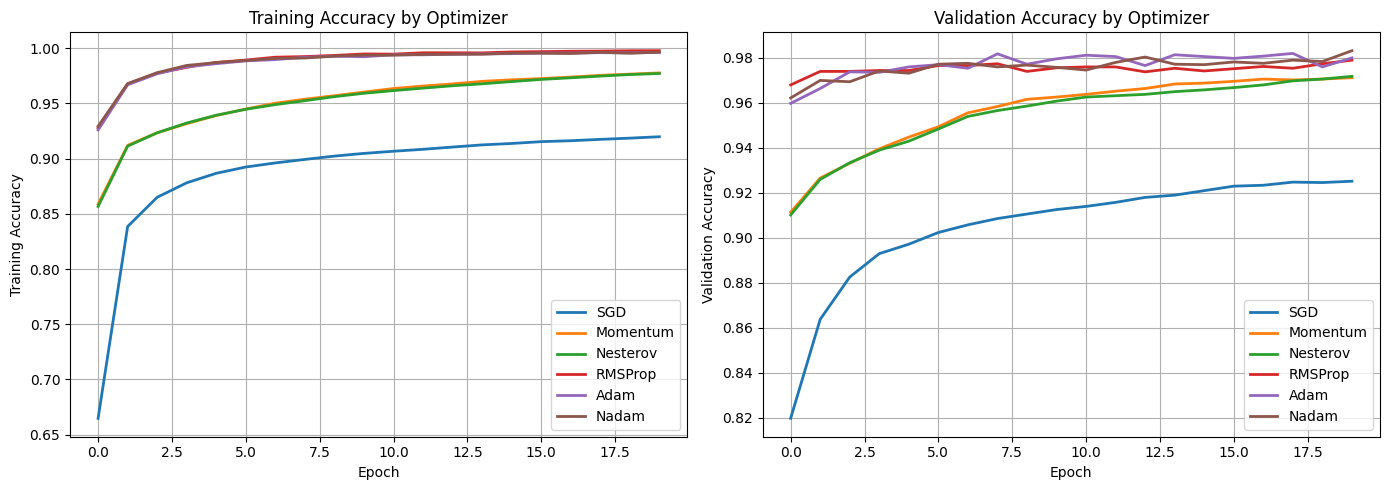


=== OPTIMIZER COMPARISON ===
Optimizer  Final Val Acc Speed Quality
      SGD         0.9252     ★     ★★★
 Momentum         0.9712    ★★     ★★★
 Nesterov         0.9718    ★★     ★★★
  RMSProp         0.9790   ★★★  ★★-★★★
     Adam         0.9800   ★★★  ★★-★★★
    Nadam         0.9832   ★★★  ★★-★★★

✓ Adam/Nadam: Fast convergence, good default choice
✓ Nesterov: Often best generalization
✓ RMSProp: Good for RNNs
⚠ SGD: Slowest but sometimes best final accuracy with proper tuning


In [40]:
# Compare all optimizers
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_sgd.history['accuracy'], label='SGD', linewidth=2)
plt.plot(history_momentum.history['accuracy'], label='Momentum', linewidth=2)
plt.plot(history_nesterov.history['accuracy'], label='Nesterov', linewidth=2)
plt.plot(history_rmsprop.history['accuracy'], label='RMSProp', linewidth=2)
plt.plot(history_adam.history['accuracy'], label='Adam', linewidth=2)
plt.plot(history_nadam.history['accuracy'], label='Nadam', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Training Accuracy')
plt.title('Training Accuracy by Optimizer')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_sgd.history['val_accuracy'], label='SGD', linewidth=2)
plt.plot(history_momentum.history['val_accuracy'], label='Momentum', linewidth=2)
plt.plot(history_nesterov.history['val_accuracy'], label='Nesterov', linewidth=2)
plt.plot(history_rmsprop.history['val_accuracy'], label='RMSProp', linewidth=2)
plt.plot(history_adam.history['val_accuracy'], label='Adam', linewidth=2)
plt.plot(history_nadam.history['val_accuracy'], label='Nadam', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy by Optimizer')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Summary table
results_df = pd.DataFrame({
    'Optimizer': ['SGD', 'Momentum', 'Nesterov', 'RMSProp', 'Adam', 'Nadam'],
    'Final Val Acc': [
        history_sgd.history['val_accuracy'][-1],
        history_momentum.history['val_accuracy'][-1],
        history_nesterov.history['val_accuracy'][-1],
        history_rmsprop.history['val_accuracy'][-1],
        history_adam.history['val_accuracy'][-1],
        history_nadam.history['val_accuracy'][-1]
    ],
    'Speed': ['★', '★★', '★★', '★★★', '★★★', '★★★'],
    'Quality': ['★★★', '★★★', '★★★', '★★-★★★', '★★-★★★', '★★-★★★']
})

print("\n=== OPTIMIZER COMPARISON ===")
print(results_df.to_string(index=False))
print("\n✓ Adam/Nadam: Fast convergence, good default choice")
print("✓ Nesterov: Often best generalization")
print("✓ RMSProp: Good for RNNs")
print("⚠ SGD: Slowest but sometimes best final accuracy with proper tuning")

---

## 9. Learning Rate Scheduling

Finding the right learning rate is crucial. Instead of using a fixed learning rate, we can **vary it during training** for better results.

### Why Schedule Learning Rates?

- **Start high**: Learn quickly in early epochs
- **Decrease gradually**: Fine-tune as we approach optimum
- **Result**: Faster convergence + better final accuracy

### Common Scheduling Strategies

### 9.1 Power Scheduling

**Formula**: η(t) = η₀ / (1 + t/s)^c

- Drops quickly then slowly
- Requires tuning η₀, s, and c
- Simplest implementation in Keras (using `decay` parameter)

### 9.2 Exponential Scheduling

**Formula**: η(t) = η₀ × 0.1^(t/s)

- Drops by factor of 10 every s steps
- Smooth exponential decay
- Popular and effective

In [41]:
# Exponential Scheduling Example
def exponential_decay_fn(epoch):
    return 0.01 * 0.1**(epoch / 20)

model_exp_schedule = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dense(10, activation="softmax")
])

model_exp_schedule.compile(loss="sparse_categorical_crossentropy",
                           optimizer="sgd",
                           metrics=["accuracy"])

lr_scheduler = keras.callbacks.LearningRateScheduler(exponential_decay_fn)

history_exp_schedule = model_exp_schedule.fit(X_train, y_train, epochs=25,
                                              validation_data=(X_valid, y_valid),
                                              callbacks=[lr_scheduler],
                                              verbose=0)

print(f"With exponential LR schedule: {history_exp_schedule.history['val_accuracy'][-1]:.4f}")

c:\Users\ASUS\anaconda3\envs\conda_env\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


With exponential LR schedule: 0.9604


### 9.3 Piecewise Constant Scheduling

Different constant rates for different epoch ranges.

**Example**:
- η = 0.01 for first 5 epochs
- η = 0.005 for epochs 5-15
- η = 0.001 for epochs 15+

Simple and interpretable!

In [42]:
# Piecewise Constant Scheduling
def piecewise_constant_fn(epoch):
    if epoch < 5:
        return 0.01
    elif epoch < 15:
        return 0.005
    else:
        return 0.001

model_piecewise = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dense(10, activation="softmax")
])

model_piecewise.compile(loss="sparse_categorical_crossentropy",
                        optimizer="sgd",
                        metrics=["accuracy"])

lr_scheduler_piecewise = keras.callbacks.LearningRateScheduler(piecewise_constant_fn)

history_piecewise = model_piecewise.fit(X_train, y_train, epochs=20,
                                        validation_data=(X_valid, y_valid),
                                        callbacks=[lr_scheduler_piecewise],
                                        verbose=0)

print(f"With piecewise constant LR: {history_piecewise.history['val_accuracy'][-1]:.4f}")

With piecewise constant LR: 0.9630


### 9.4 Performance Scheduling (ReduceLROnPlateau)

**Adaptive approach**: Reduce learning rate when validation error plateaus.

**How it works**:
- Monitor validation loss/accuracy
- If no improvement for `patience` epochs, multiply LR by `factor`
- Example: factor=0.5, patience=5 → cut LR in half after 5 epochs without improvement

**Advantage**: Automatically adapts to your specific problem!

In [43]:
# Performance Scheduling (ReduceLROnPlateau)
model_plateau = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dense(10, activation="softmax")
])

model_plateau.compile(loss="sparse_categorical_crossentropy",
                      optimizer=keras.optimizers.SGD(learning_rate=0.01),
                      metrics=["accuracy"])

lr_scheduler_plateau = keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5)

history_plateau = model_plateau.fit(X_train, y_train, epochs=30,
                                    validation_data=(X_valid, y_valid),
                                    callbacks=[lr_scheduler_plateau],
                                    verbose=0)

print(f"With ReduceLROnPlateau: {history_plateau.history['val_accuracy'][-1]:.4f}")

With ReduceLROnPlateau: 0.9752


### 9.5 Visualizing Learning Rate Schedules

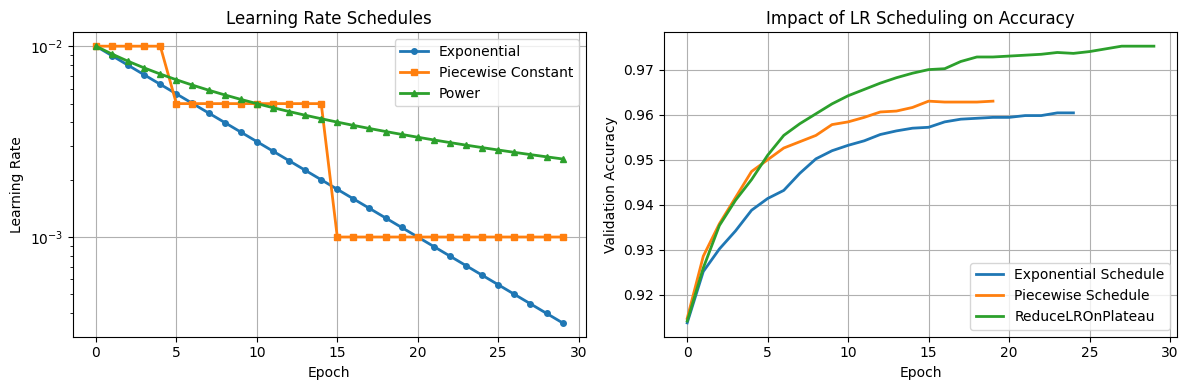


✓ Learning rate scheduling can significantly improve convergence!
✓ ReduceLROnPlateau is often the easiest to use (automatic)


In [44]:
# Visualize different learning rate schedules
epochs = np.arange(30)

# Exponential decay
lr_exp = [exponential_decay_fn(e) for e in epochs]

# Piecewise constant
lr_piecewise = [piecewise_constant_fn(e) for e in epochs]

# Power decay (approximation)
lr_power = [0.01 / (1 + e/10) for e in epochs]

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, lr_exp, label='Exponential', linewidth=2, marker='o', markersize=4)
plt.plot(epochs, lr_piecewise, label='Piecewise Constant', linewidth=2, marker='s', markersize=4)
plt.plot(epochs, lr_power, label='Power', linewidth=2, marker='^', markersize=4)
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.title('Learning Rate Schedules')
plt.legend()
plt.grid(True)
plt.yscale('log')

plt.subplot(1, 2, 2)
plt.plot(history_exp_schedule.history['val_accuracy'], label='Exponential Schedule', linewidth=2)
plt.plot(history_piecewise.history['val_accuracy'], label='Piecewise Schedule', linewidth=2)
plt.plot(history_plateau.history['val_accuracy'], label='ReduceLROnPlateau', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Impact of LR Scheduling on Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("\n✓ Learning rate scheduling can significantly improve convergence!")
print("✓ ReduceLROnPlateau is often the easiest to use (automatic)")

---

## Summary: Part 3 (Next 25%)

### What We Covered

#### 6. Unsupervised Pretraining
- Use when you have abundant **unlabeled data** but limited labeled data
- Train autoencoder/GAN on unlabeled data → transfer features
- Historical technique that revived deep learning (2006)
- Less common now but still valuable in data-scarce scenarios

#### 7. Pretraining on Auxiliary Task
- Train on related task with abundant data → transfer to target task
- **Self-supervised learning**: Auto-generate labels from data structure
- Examples: Face similarity, masked word prediction (BERT)
- Very powerful when you lack labeled data for your specific task

#### 8. Faster Optimizers

| Optimizer | How It Works | Speed | When to Use |
|-----------|--------------|-------|-------------|
| **SGD** | Basic gradient descent | ★ | Baseline, sometimes best with tuning |
| **Momentum** | Accumulates velocity | ★★ | Good default, faster than SGD |
| **Nesterov** | Lookahead momentum | ★★ | Often best generalization |
| **AdaGrad** | Adaptive per-parameter rates | ★★★ | Avoid (stops too early) |
| **RMSProp** | Exponential moving average | ★★★ | Great for RNNs |
| **Adam** | Momentum + RMSProp | ★★★ | **Default choice**, works well generally |
| **Nadam** | Adam + Nesterov | ★★★ | Slightly better than Adam |

**Key Insights**:
- **Adam/Nadam**: Fast, adaptive, good defaults (lr=0.001)
- **Nesterov SGD**: Sometimes better final accuracy
- **RMSProp**: Good for recurrent networks

#### 9. Learning Rate Scheduling

| Schedule | Formula | Use Case |
|----------|---------|----------|
| **Power** | η(t) = η₀/(1+t/s)^c | Simple decay |
| **Exponential** | η(t) = η₀ × 0.1^(t/s) | Smooth decay |
| **Piecewise** | Different rates per epoch range | Interpretable, manual control |
| **ReduceLROnPlateau** | Reduce when validation plateaus | **Automatic, easiest** ✓ |
| **1cycle** | Increase then decrease | Often best performance |

**Benefits**:
- Faster convergence
- Better final accuracy  
- Less hyperparameter tuning needed

### Practical Guidelines

**Optimizer Choice**:
1. Start with **Adam** (lr=0.001) - works well for most problems
2. If disappointed, try **Nesterov SGD** with momentum=0.9
3. For RNNs specifically, consider **RMSProp**

**Learning Rate Scheduling**:
1. Start with **ReduceLROnPlateau** (easiest, automatic)
2. Or try **exponential decay**
3. For best results, experiment with **1cycle** (covered in exercises)

**General Workflow**:
1. Use proper initialization (He/LeCun)
2. Choose good activation (ELU/SELU)
3. Add Batch Normalization if deep
4. Use Adam optimizer with default settings
5. Add ReduceLROnPlateau callback
6. Monitor training curves
7. Fine-tune if needed

### Next Section Preview

In the final section (Part 4), we'll cover:
- **Regularization Techniques**: L1/L2, Dropout, MC Dropout, Max-Norm
- **Training Sparse Models**: Model optimization
- **Final Summary**: Complete guidelines and best practices

---

**Continue to Part 4 for regularization and the complete practical guide!**

---

## 10. Regularization Techniques

Regularization helps prevent **overfitting** - when the model learns the training data too well, including noise, and performs poorly on new data.

### The Overfitting Problem

Deep networks with millions of parameters can easily memorize training data. Regularization techniques constrain the model to learn generalizable patterns instead.

### 10.1 ℓ1 and ℓ2 Regularization

**Concept**: Add a penalty term to the loss function based on weight magnitudes.

**ℓ2 Regularization (Ridge)**:
- Penalty: Σ(w²)
- Encourages small weights
- Smooth weight shrinkage
- Most common choice

**ℓ1 Regularization (Lasso)**:
- Penalty: Σ(|w|)
- Encourages **sparse** models (many weights = 0)
- Useful for feature selection
- Can completely eliminate unimportant features

**Combined (Elastic Net)**: Use both ℓ1 and ℓ2

In [45]:
# Model with ℓ2 Regularization
from functools import partial

RegularizedDense = partial(keras.layers.Dense,
                          activation="elu",
                          kernel_initializer="he_normal",
                          kernel_regularizer=keras.regularizers.l2(0.01))

model_l2 = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    RegularizedDense(300),
    RegularizedDense(100),
    keras.layers.Dense(10, activation="softmax")
])

model_l2.compile(loss="sparse_categorical_crossentropy",
                 optimizer="nadam",
                 metrics=["accuracy"])

print("Model with ℓ2 regularization:")
model_l2.summary()

# Model with ℓ1 Regularization (sparse model)
model_l1 = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="elu", 
                      kernel_initializer="he_normal",
                      kernel_regularizer=keras.regularizers.l1(0.01)),
    keras.layers.Dense(100, activation="elu", 
                      kernel_initializer="he_normal",
                      kernel_regularizer=keras.regularizers.l1(0.01)),
    keras.layers.Dense(10, activation="softmax")
])

model_l1.compile(loss="sparse_categorical_crossentropy",
                 optimizer="nadam",
                 metrics=["accuracy"])

print("\nModel with ℓ1 regularization (encourages sparsity):")

Model with ℓ2 regularization:


Model: "sequential_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_25 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_85 (Dense)                │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_86 (Dense)                │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_87 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)


Model with ℓ1 regularization (encourages sparsity):


### 10.2 Dropout

**Concept**: Randomly "drop" (set to 0) neurons during training.

**How it Works**:
- Each training step: every neuron has probability **p** of being dropped
- **Dropout rate (p)**: Typically 0.2-0.5
- At test time: use all neurons, but scale outputs by (1-p)

**Why it Works**:
- Prevents **co-adaptation** of neurons (neurons becoming too dependent on each other)
- Forces network to learn **robust features**
- Like training an **ensemble** of 2^N different networks
- Acts as powerful regularizer

**Guidelines**:
- Increase dropout if overfitting
- Decrease if underfitting
- Higher rates for large layers, lower for small layers
- Many architectures only use dropout after last hidden layer
- Slows convergence but improves generalization

In [46]:
# Model with Dropout
model_dropout = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dropout(rate=0.2),
    keras.layers.Dense(300, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dropout(rate=0.2),
    keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dropout(rate=0.2),
    keras.layers.Dense(10, activation="softmax")
])

model_dropout.compile(loss="sparse_categorical_crossentropy",
                      optimizer="nadam",
                      metrics=["accuracy"])

print("Training model with Dropout...")
history_dropout = model_dropout.fit(X_train, y_train, epochs=20,
                                    validation_data=(X_valid, y_valid),
                                    verbose=0)

print(f"Final validation accuracy: {history_dropout.history['val_accuracy'][-1]:.4f}")

# Compare with model without dropout
model_no_dropout = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dense(10, activation="softmax")
])

model_no_dropout.compile(loss="sparse_categorical_crossentropy",
                         optimizer="nadam",
                         metrics=["accuracy"])

history_no_dropout = model_no_dropout.fit(X_train, y_train, epochs=20,
                                          validation_data=(X_valid, y_valid),
                                          verbose=0)

print(f"Without dropout: {history_no_dropout.history['val_accuracy'][-1]:.4f}")

Training model with Dropout...
Final validation accuracy: 0.9846
Without dropout: 0.9784


### 10.3 Monte Carlo (MC) Dropout

**Powerful 2016 technique** by Gal and Ghahramani that boosts any trained dropout model!

**Key Insight**: Keep dropout **active during inference** and make multiple predictions.

**Benefits**:
1. **Better predictions**: Averaging reduces variance
2. **Uncertainty estimates**: Standard deviation tells you confidence
3. **No retraining needed**: Works with any dropout model
4. **Simple to implement**: Just a few lines of code

**Trade-off**: Slower inference (need multiple forward passes)

In [49]:
# Monte Carlo Dropout Demo
print("Demonstrating Monte Carlo Dropout...")

# Use the dropout model we trained earlier
# Make sure to use standardized test data
X_test_scaled_mc = (X_test - pixel_means) / (pixel_stds + 1e-7)

# Single prediction (standard approach)
y_pred_single = model_dropout(X_test_scaled_mc[:10], training=False)

# MC Dropout: Multiple predictions with dropout active
n_samples = 100
y_probas = np.stack([
    model_dropout(X_test_scaled_mc[:10], training=True).numpy()
    for _ in range(n_samples)
])

# Average predictions
y_pred_mc = y_probas.mean(axis=0)

# Uncertainty estimates (standard deviation)
y_std_mc = y_probas.std(axis=0)

print("\n=== MC Dropout Results (first 3 test samples) ===")
for i in range(3):
    true_label = y_test[i]
    single_pred = np.argmax(y_pred_single[i])
    mc_pred = np.argmax(y_pred_mc[i])
    uncertainty = y_std_mc[i].mean()
    
    print(f"\nSample {i+1}:")
    print(f"  True label: {true_label}")
    print(f"  Single prediction: {single_pred} (confidence: {tf.reduce_max(y_pred_single[i]).numpy():.3f})")
    print(f"  MC Dropout prediction: {mc_pred} (confidence: {tf.reduce_max(y_pred_mc[i]).numpy():.3f})")
    print(f"  Average uncertainty: {uncertainty:.3f}")

print("\n✓ MC Dropout provides:")
print("  - More reliable predictions (averaged over 100 samples)")
print("  - Uncertainty estimates for risk-sensitive applications")

Demonstrating Monte Carlo Dropout...

=== MC Dropout Results (first 3 test samples) ===

Sample 1:
  True label: 7
  Single prediction: 7 (confidence: 1.000)
  MC Dropout prediction: 7 (confidence: 1.000)
  Average uncertainty: 0.000

Sample 2:
  True label: 2
  Single prediction: 2 (confidence: 1.000)
  MC Dropout prediction: 2 (confidence: 1.000)
  Average uncertainty: 0.000

Sample 3:
  True label: 1
  Single prediction: 1 (confidence: 1.000)
  MC Dropout prediction: 1 (confidence: 0.981)
  Average uncertainty: 0.026

✓ MC Dropout provides:
  - More reliable predictions (averaged over 100 samples)
  - Uncertainty estimates for risk-sensitive applications


### 10.4 Max-Norm Regularization

**Concept**: Constrain the norm of incoming connection weights per neuron.

**Constraint**: ‖w‖₂ ≤ r

**How it works**:
- After each training step, check weight norm
- If ‖w‖₂ > r, rescale: w ← w × r/‖w‖₂
- Prevents weights from growing too large
- Helps with gradient instability

**Use cases**:
- Combine with dropout for better results
- Useful when dealing with unstable gradients
- Common in certain architectures (especially with RNNs)

In [50]:
# Model with Max-Norm Regularization
model_maxnorm = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="elu", 
                      kernel_initializer="he_normal",
                      kernel_constraint=keras.constraints.max_norm(1.0)),
    keras.layers.Dense(100, activation="elu", 
                      kernel_initializer="he_normal",
                      kernel_constraint=keras.constraints.max_norm(1.0)),
    keras.layers.Dense(10, activation="softmax")
])

model_maxnorm.compile(loss="sparse_categorical_crossentropy",
                      optimizer="nadam",
                      metrics=["accuracy"])

print("Model with Max-Norm constraint (max_norm=1.0):")
print("  Incoming weights to each neuron are constrained to have norm ≤ 1.0")
print("  This helps prevent exploding gradients and overfitting")

Model with Max-Norm constraint (max_norm=1.0):
  Incoming weights to each neuron are constrained to have norm ≤ 1.0
  This helps prevent exploding gradients and overfitting


c:\Users\ASUS\anaconda3\envs\conda_env\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Regularization Summary

**Comparison of Regularization Techniques**:

| Technique | Effect | When to Use | Computational Cost |
|-----------|--------|-------------|-------------------|
| ℓ2 | Shrinks all weights | General purpose | Low |
| ℓ1 | Sparse weights (some = 0) | Feature selection | Low |
| Dropout | Randomly drops neurons | Prevents co-adaptation | Medium (slows training) |
| MC Dropout | Multiple predictions | Uncertainty estimates | High (inference only) |
| Max-Norm | Constrains weight magnitude | Unstable gradients | Low |
| Batch Norm | Normalizes activations | Deep networks | Medium |

**Best Practices**:
1. **Start with early stopping** (always use!)
2. Add **ℓ2 regularization** if still overfitting
3. Try **dropout** for very deep networks or limited data
4. Use **MC Dropout** for risk-sensitive applications
5. **Batch Normalization** often reduces need for other regularization

---

## 11. Training Sparse Models

For **faster runtime** or **reduced memory**, you may want sparse models (many weights = 0).

### Why Sparsity?

- **Faster inference**: Skip computations for zero weights
- **Smaller models**: Compress and deploy more easily
- **Interpretability**: Fewer connections are easier to understand

### Approaches to Sparsity

**1. Post-Training Pruning**:
- Train normally
- Remove (zero out) tiny weights
- Optionally fine-tune
- Simple but requires full training first

**2. ℓ1 Regularization**:
- Encourages sparsity during training
- Many weights driven to exactly 0
- Network learns sparse structure

**3. TensorFlow Model Optimization Toolkit (TF-MOT)**:
- Iteratively removes connections during training
- Removes by magnitude (smallest weights first)
- More sophisticated than simple ℓ1
- Maintains accuracy better

**Note**: Sparsity breaks self-normalization property of SELU networks.

In [51]:
# Example: ℓ1 regularization creates sparse models
# Train the ℓ1 model we created earlier
history_l1 = model_l1.fit(X_train, y_train, epochs=10,
                          validation_data=(X_valid, y_valid),
                          verbose=0)

# Examine weight sparsity
weights = model_l1.layers[1].get_weights()[0]  # First hidden layer weights
total_weights = weights.size
zero_weights = np.sum(np.abs(weights) < 0.01)  # Count near-zero weights
sparsity = zero_weights / total_weights * 100

print(f"ℓ1 Regularization Sparsity Analysis:")
print(f"  Total weights: {total_weights}")
print(f"  Near-zero weights (|w| < 0.01): {zero_weights}")
print(f"  Sparsity: {sparsity:.1f}%")
print(f"\n✓ ℓ1 regularization naturally creates sparse models!")
print(f"✓ Sparse models are faster and use less memory")

ℓ1 Regularization Sparsity Analysis:
  Total weights: 235200
  Near-zero weights (|w| < 0.01): 234684
  Sparsity: 99.8%

✓ ℓ1 regularization naturally creates sparse models!
✓ Sparse models are faster and use less memory


---

## FINAL SUMMARY: Training Deep Neural Networks

### Complete Toolkit

We've covered all major techniques for training deep neural networks effectively:

### 1. **Gradient Problems** 
**Solutions:**
- **Proper initialization**: He (ReLU), Glorot (tanh), LeCun (SELU)
- **Better activations**: ELU > ReLU > tanh > sigmoid
- **Batch Normalization**: Normalizes layer inputs
- **Gradient Clipping**: Prevents explosion

### 2. **Training Speed**
**Solutions:**
- **Better optimizers**: Adam/Nadam > RMSProp > Momentum > SGD
- **Learning rate schedules**: Exponential, 1cycle, ReduceLROnPlateau
- **Batch Normalization**: Allows higher learning rates
- **Transfer Learning**: Reuse pretrained models

### 3. **Overfitting**
**Solutions:**
- **Early stopping** (always!)
- **ℓ2/ℓ1 regularization**: Constrain weights
- **Dropout**: Random neuron dropping
- **Data augmentation** (not covered here, but very effective)
- **More training data**

### 4. **Limited Data**
**Solutions:**
- **Transfer Learning**: Reuse pretrained layers
- **Unsupervised Pretraining**: Use unlabeled data
- **Auxiliary Task Pretraining**: Train on related task
- **Data augmentation**

### Default Configuration Recommendations

### **Standard Deep Network**

| Hyperparameter | Recommended Value |
|---------------|-------------------|
| **Initialization** | He initialization |
| **Activation** | ELU |
| **Normalization** | None (shallow); Batch Norm (deep) |
| **Regularization** | Early stopping (+ ℓ2 if needed) |
| **Optimizer** | Nadam or Adam |
| **Learning Rate Schedule** | ReduceLROnPlateau or 1cycle |

```python
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(300, activation="elu", kernel_initializer="he_normal"),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal"),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(10, activation="softmax")
])

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=keras.optimizers.Nadam(learning_rate=0.001),
    metrics=["accuracy"]
)

early_stop = keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
lr_schedule = keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5)

history = model.fit(X_train, y_train, epochs=100,
                   validation_data=(X_valid, y_valid),
                   callbacks=[early_stop, lr_schedule])
```

### **Self-Normalizing Network** (Sequential Dense Only)

| Hyperparameter | Recommended Value |
|---------------|-------------------|
| **Initialization** | LeCun initialization |
| **Activation** | SELU |
| **Normalization** | None (self-normalizing!) |
| **Regularization** | Alpha Dropout (if needed) |
| **Optimizer** | Nadam or Momentum SGD |
| **Learning Rate Schedule** | 1cycle |

```python
# Standardize inputs first!
X_mean = X_train.mean(axis=0, keepdims=True)
X_std = X_train.std(axis=0, keepdims=True)
X_train_scaled = (X_train - X_mean) / (X_std + 1e-7)

model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.Dense(100, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.Dense(10, activation="softmax")
])
```

### Decision Flow Chart

**Building a Deep Neural Network? Follow this guide:**

```
START
  ↓
1. Do you have a similar pretrained model?
   YES → Use Transfer Learning
   NO  → Continue
  ↓
2. Is your network very deep (>10 layers)?
   YES → Use Batch Normalization
   NO  → Continue
  ↓
3. Choose activation function:
   - Sequential dense layers → SELU (self-normalizing)
   - Other architectures → ELU or ReLU
  ↓
4. Choose initialization:
   - SELU → LeCun
   - ReLU/ELU → He
   - tanh/sigmoid → Glorot
  ↓
5. Choose optimizer:
   - Default → Adam or Nadam
   - Best generalization → Nesterov SGD (with tuning)
  ↓
6. Add learning rate schedule:
   - Easy → ReduceLROnPlateau
   - Best → 1cycle
  ↓
7. Regularization (in order):
   a. Early stopping (always!)
   b. ℓ2 regularization (if overfitting)
   c. Dropout (if still overfitting)
  ↓
8. Special cases:
   - Risk-sensitive? → Add MC Dropout
   - Need speed? → Create sparse model (ℓ1)
   - RNN? → Add gradient clipping
  ↓
END: Train and monitor validation loss!
```

### Key Takeaways

**7 Essential Principles:**

1. **Gradient Problems**: Use He/Glorot initialization + ELU/SELU/ReLU activation
   - Avoid sigmoid/tanh in hidden layers
   - Add Batch Normalization for very deep networks

2. **Batch Normalization**: Powerful for deep networks
   - Reduces sensitivity to initialization
   - Allows higher learning rates
   - Acts as regularizer

3. **Transfer Learning**: Always check for pretrained models first
   - Dramatically speeds up training
   - Requires less data
   - Often achieves better results

4. **Optimizers**: Adam/Nadam work well generally
   - Try Nesterov SGD if adaptive methods underperform
   - Use learning rate scheduling for best results

5. **Learning Rate Scheduling**: Critical for optimal performance
   - ReduceLROnPlateau: Easy and automatic
   - 1cycle: Often best results

6. **Regularization**: Prevent overfitting systematically
   - Early stopping (always!)
   - ℓ2 regularization
   - Dropout for deep networks
   - Batch Norm also acts as regularizer

7. **MC Dropout**: For uncertainty estimates
   - No retraining needed
   - Better predictions
   - Essential for risk-sensitive applications

### Common Pitfalls to Avoid

❌ **Don't:**
- Use sigmoid/tanh in hidden layers (use ReLU/ELU instead)
- Forget to standardize inputs for SELU networks
- Use same learning rate when fine-tuning (reduce it!)
- Forget to compile after freezing/unfreezing layers
- Use too much regularization (underfit) or too little (overfit)
- Ignore early stopping (easiest way to prevent overfitting)
- Train deep networks without Batch Normalization
- Use default weight initialization with wrong activation

✅ **Do:**
- Monitor both training AND validation metrics
- Use callbacks (EarlyStopping, ReduceLROnPlateau)
- Try transfer learning before training from scratch
- Start simple, add complexity as needed
- Visualize training curves to diagnose problems
- Use proper initialization for your activation function
- Standardize/normalize input data
- Save your best models

### Quick Reference Table

| Problem | Solution |
|---------|----------|
| Vanishing gradients | He/Glorot init + ReLU/ELU/SELU |
| Exploding gradients | Gradient clipping, BN, proper init |
| Training too slow | Adam/Nadam, learning rate schedule, BN |
| Overfitting | Early stopping, ℓ2/Dropout, more data |
| Underfitting | Bigger model, longer training, less regularization |
| Limited labeled data | Transfer learning, data augmentation |
| Need uncertainty | MC Dropout |
| Need speed/memory | Sparse models (ℓ1), model compression |
| Very deep network | Batch Normalization, skip connections |
| Poor initialization | He (ReLU), Glorot (tanh), LeCun (SELU) |

---

## 🎯 Congratulations!

You've now completed Chapter 11: Training Deep Neural Networks! 

You've learned:
- ✅ How to handle vanishing and exploding gradients
- ✅ When to use different weight initialization strategies
- ✅ How to choose and apply activation functions
- ✅ When and how to use Batch Normalization
- ✅ How to implement gradient clipping
- ✅ How to perform transfer learning
- ✅ Multiple optimization algorithms and when to use them
- ✅ Learning rate scheduling strategies
- ✅ Various regularization techniques
- ✅ How to train sparse models

### Next Steps

1. **Practice**: Try these techniques on your own datasets
2. **Experiment**: Compare different combinations of techniques
3. **Monitor**: Always visualize training curves and metrics
4. **Iterate**: Don't expect perfection on the first try
5. **Read**: Dive deeper into the papers referenced in the original README

### Exercise Ideas

1. Build a deep network (10+ layers) for CIFAR-10 using the techniques learned
2. Compare 3 different optimizers on the same architecture
3. Implement a complete transfer learning pipeline with fine-tuning
4. Add uncertainty estimation using MC Dropout to a classification problem
5. Create a sparse model and compare its efficiency to a dense baseline

Happy deep learning! 🚀